# XSEA null-set structure: are real sets special?

XSEA (X-Set Enrichment Analysis) tests whether a brain map aligns with a *group* of reference
maps (a gene set, a PET tracer family, a Neurosynth cognitive domain) more than expected by
chance. NiSpace's default null (`permute(what="maps")`) keeps the observed sets fixed and
permutes the target map's spatial structure instead — this follows Fulcher, Arnatkeviciute &
Fornito (2021, *Nat. Commun.* 12:2669), who showed that the alternative — resampling random
*sets* from a background pool (`permute(what="sets")`) — inflates false positives by **>500-fold**
when set members are more intercorrelated with each other than a random draw would be. Real
gene sets (defined by shared biology) are almost always more internally coherent than random
gene draws, and a naive set-resampling null does not know that, so it under-estimates how easily
a spuriously "significant" set-mean could arise by chance alone.

Wei et al. (2022, *Hum Brain Mapp* 43:885-901, the **GAMBA** toolbox) address this for
hypothesis-driven single-gene-set testing with a **coexpression-matched null**: draw random gene
sets whose mean pairwise coexpression matches the real set's, instead of drawing uniformly. NiSpace
issue #75 asks for the same idea for `what="sets"` XSEA nulls — generalized beyond genes, since
XSEA sets can equally be PET maps grouped by molecular target or Neurosynth maps grouped by
cognitive domain. We call this an **intercorrelation-matched null** (`intercorr_matched`) rather
than "coexpression-matched", since "coexpression" is gene-specific terminology.

**This notebook is step 1+2 of a larger plan**: build the benchmarking notebook and run a first,
fully-working exploration of the premise the whole feature rests on — *are real XSEA sets actually
more intercorrelated than a random same-size draw, across the collections NiSpace ships?* If not,
matching would have nothing to correct for. Alongside intercorrelation we also check two related
per-set properties that came up during design discussion as possible additional matching features:
**effective dimensionality** (Galwey `meff`, i.e. how redundant the set's members are) and **mean
spatial autocorrelation** of set members (a distinct mechanism from intercorrelation, per Fulcher
et al. 2021 vs. the coexpression-null literature).

A companion notebook testing statistical **power** (true-positive rate under a matched vs.
unmatched null, once the matching itself is implemented) is planned as a separate "second"
notebook in this pair (not started here — this notebook is exploratory/descriptive only, no
implementation of the matched null itself).

In [4]:
# ── Configuration ─────────────────────────────────────────────────────────────
PARCELLATION = "Yan200"          # cortex-only: required for MAGICC, shared across all dataset types
SPACE        = "MNI152NLin6Asym"
SEED         = 42

N_RANDOM  = 200   # random size-matched background draws per distinct observed set size
N_SETS_MAX = 100  # cap on the number of real sets analyzed per (dataset, collection);
                  # random subsample (seeded) when a collection has more than this

# gene sets: size must be > 2 (need >= 2 members for a pairwise intercorrelation, > 2 for a
# meaningful distribution) and <= 300 to stay in the range XSEA is realistically applied to.
# This deliberately excludes CorticalLayers and most of ProteinAtlas, whose "sets" are broad
# expression tiers with hundreds-to-thousands of members (not the compact, specific sets XSEA
# is normally run on) -- revisit later if that turns out to matter.
GENE_SET_SIZE_RANGE = (3, 300)
PET_SET_SIZE_RANGE  = (2, None)   # PET target families are small by nature -- keep pairs (size 2)
NSYN_SET_SIZE_RANGE = (3, None)

# all non-"*Weights" gene-set collections shared by both mRNA datasets (Weights variants have
# identical sets/members, just an added weight column -- no need to profile both, see memory)
GENE_COLLECTIONS = [
    "ASDModulesGandal2022", "BrainSpan", "CellTypesPsychEncodeTPM", "CellTypesPsychEncodeUMI",
    "CellTypesSilettiClusters", "CellTypesSilettiSuperclusters", "Chromosome",
    "GOBiologicalProcess", "GOCellularComponent", "GOMolecularFunction", "SynGO",
]

# (dataset, collection, set_size_range) -- "All" is used as the background/null pool for every
# dataset (the same pool `what="sets"` uses today by default)
CONDITIONS = (
    [("mrna",   c, GENE_SET_SIZE_RANGE) for c in GENE_COLLECTIONS] +
    [("magicc", c, GENE_SET_SIZE_RANGE) for c in GENE_COLLECTIONS] +   # continuous reconstruction:
                                                                        # may show higher intercorrelation
    [("pet",        "AllTargetSets",      PET_SET_SIZE_RANGE)] +
    [("neurosynth",  "CognitiveFunctions", NSYN_SET_SIZE_RANGE)]
)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

from nispace.datasets import fetch_reference, fetch_parcellation
from nispace.stats.autocorr import morans_i

dist_mat = fetch_parcellation(PARCELLATION).get_dist_mat(SPACE)

INFO | 17/07/26 08:42:06 | nispace.core.parcellation: Building cortex Parcellation for 'Yan200' from library. DOI: 10.1016/j.neuroimage.2023.120010
INFO | 17/07/26 08:42:06 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsLR, fsaverage
INFO | 17/07/26 08:42:06 | nispace.core.parcellation: Parcellation 'Yan200': validation passed.
INFO | 17/07/26 08:42:06 | nispace.core.parcellation: Lazy-loading dist mat for 'Yan200' in space 'MNI152NLin6Asym'.


## Benchmark design

For every `(dataset, collection)` condition:

1. Fetch the collection's sets (`fetch_reference(..., collection=..., set_size_range=...)`) and
   the dataset's full unrestricted map pool as the background (`collection="All"`) -- the same
   pool `permute(what="sets")` draws from today.
2. If a collection has more than `N_SETS_MAX` sets, randomly subsample down to `N_SETS_MAX`
   (seeded) -- purely a runtime concession for very large collections (e.g. >7,000 GO terms);
   the goal here is a representative first look, not an exhaustive census.
3. For each selected real set, and for `N_RANDOM` random same-size draws from the background,
   compute 4 per-set statistics:
   - **`pearson_ic`** / **`spearman_ic`**: mean pairwise intercorrelation among set members
     (upper triangle of the members' correlation matrix, both families computed -- which one is
     "the" relevant one depends on the eventual colocalization method, see design memory).
   - **`moran`**: mean Moran's I across set members (spatial autocorrelation of the *individual*
     maps -- a different mechanism from intercorrelation *between* maps).
   - **`meff`**: Galwey effective dimensionality of the set's members (how many independent
     "pieces of information" the set actually contains).
4. Random draws are generated **once per distinct set size** within a condition, not once per
   real set (a real set's own statistic is cheap; building its null comparison is not) --
   this is the same "candidate library keyed by size" idea the eventual `intercorr_matched`
   sampler will use, and this notebook is a first proof that the underlying trick (below) makes
   it fast enough to run at scale.
5. Each real set's statistic is expressed as a **percentile rank** against its size-matched null
   distribution (`mean(null <= real) * 100`) -- this is the direct, model-free way to ask "is
   this set unusual", and is what the load-bearing premise (real sets are elevated in
   intercorrelation) predicts should skew high.

**Avoiding an O(N²) background correlation matrix**: computing a full pairwise-correlation
matrix over an 11,000-gene background is both wasteful (only ever need small subsets of it) and
memory-heavy. Instead we precompute each background map's **z-scored row** (and, for the Spearman
family, its rank-transformed-then-z-scored row) **once**. For any subset of `k` background rows,
their correlation matrix is then just `Z[idx] @ Z[idx].T / n_parcels` -- a `k×k` matmul, not a
lookup into a pre-built `N×N` matrix. Moran's I is a per-map property (does not depend on which
set a map belongs to), so it is precomputed **once per background map** and simply averaged over
whichever members a given set/draw contains, rather than recomputed per set. Together these make
what would otherwise be ~10<sup>5</sup>–10<sup>6</sup> pandas-level correlation calls into a
handful of vectorized numpy operations per condition (empirically ~35× faster in a first
timing test on the largest collection here, GOBiologicalProcess/mRNA).

In [5]:
# ── Helper functions ──────────────────────────────────────────────────────────

def precompute_background(dataset, parcellation):
    """Fetch a dataset's full map pool and precompute per-row z-scored (Pearson) and
    rank-then-z-scored (Spearman) rows, plus per-row Moran's I, once."""
    bg = fetch_reference(dataset, parcellation=parcellation, collection="All", verbose=False)
    X = bg.values.astype(np.float64)
    # drop parcels with any NaN across the background (mirrors compute_meff's own NaN handling)
    keep = ~np.isnan(X).any(axis=0)
    X = X[:, keep]
    n_parcels = X.shape[1]

    Zp = (X - X.mean(axis=1, keepdims=True)) / X.std(axis=1, keepdims=True, ddof=0)
    rank = pd.DataFrame(X).rank(axis=1).values
    Zs = (rank - rank.mean(axis=1, keepdims=True)) / rank.std(axis=1, keepdims=True, ddof=0)
    moran_all = np.array([morans_i(row, dist_mat) for row in X])
    label_to_idx = {lab: i for i, lab in enumerate(bg.index)}

    return dict(Zp=Zp, Zs=Zs, moran=moran_all, n_parcels=n_parcels,
                label_to_idx=label_to_idx, n_bg=X.shape[0])


def _mean_upper_tri(mat):
    iu = np.triu_indices_from(mat, k=1)
    return float(np.nanmean(mat[iu]))


def _meff_from_corr(corr):
    """Galwey (2009) effective-dimensionality, given a precomputed correlation matrix
    (same formula as nispace.stats.misc.compute_meff, inlined to reuse the matmul above
    instead of recomputing corrcoef from raw data)."""
    eig = np.linalg.eigvalsh(corr)
    eig = eig[eig > 0]
    return float(np.sum(np.sqrt(eig)) ** 2 / np.sum(eig))


def stats_from_idx(idx, bg):
    """Per-set statistics for background row indices `idx` (a real set or a random draw)."""
    idx = np.asarray(idx)
    k = len(idx)
    out = dict(size=k, moran=float(bg["moran"][idx].mean()))
    if k >= 2:
        zp = bg["Zp"][idx]
        zs = bg["Zs"][idx]
        cp = zp @ zp.T / bg["n_parcels"]
        cs = zs @ zs.T / bg["n_parcels"]
        out["pearson_ic"]  = _mean_upper_tri(cp)
        out["spearman_ic"] = _mean_upper_tri(cs)
        out["meff"] = _meff_from_corr(cp)
    else:
        out["pearson_ic"] = np.nan
        out["spearman_ic"] = np.nan
        out["meff"] = 1.0
    return out


def percentile_rank(real_value, null_values):
    return float(np.mean(np.asarray(null_values) <= real_value) * 100)


def run_condition(dataset, collection, set_size_range, bg, n_sets_max, n_random, seed):
    """Real-set statistics + size-matched null comparison for one (dataset, collection).

    Returns (records, null_pooled): `null_pooled` concatenates the size-matched background
    draws across every distinct set size encountered in this condition -- a proxy for "the
    whole null sample" this condition's real sets are compared against, used to draw reference
    percentile lines rather than converting every point to a percentile individually."""
    rng = np.random.default_rng(seed)

    df = fetch_reference(dataset, parcellation=PARCELLATION, collection=collection,
                          set_size_range=set_size_range, verbose=False)
    set_names = df.index.get_level_values("set").unique()
    if len(set_names) > n_sets_max:
        set_names = rng.choice(set_names, size=n_sets_max, replace=False)

    size_null_cache = {}
    records = []
    for s in set_names:
        labs = df.loc[s].index.get_level_values("map")  # handles plain + weighted (set/map/weight) collections
        idx = np.array([bg["label_to_idx"][l] for l in labs if l in bg["label_to_idx"]])
        real = stats_from_idx(idx, bg)
        k = real["size"]

        if k not in size_null_cache:
            draws = [
                stats_from_idx(rng.choice(bg["n_bg"], size=k, replace=False), bg)
                for _ in range(n_random)
            ]
            size_null_cache[k] = pd.DataFrame(draws)
        null = size_null_cache[k]

        rec = dict(dataset=dataset, collection=collection, set=s, size=k)
        for metric in ["pearson_ic", "spearman_ic", "moran", "meff"]:
            rec[metric] = real[metric]
            rec[f"{metric}_null_mean"] = float(null[metric].mean())
            rec[f"{metric}_pct"] = percentile_rank(real[metric], null[metric])
        records.append(rec)

    null_pooled = pd.concat(size_null_cache.values(), ignore_index=True) if size_null_cache else pd.DataFrame()
    return records, null_pooled

In [6]:
# ── Run all conditions ────────────────────────────────────────────────────────
backgrounds = {}
records = []
null_pooled = {}   # condition label -> pooled null-draw DataFrame (all sizes seen in that condition)

for dataset, collection, set_size_range in CONDITIONS:
    if dataset not in backgrounds:
        print(f"Precomputing background for '{dataset}' ...")
        backgrounds[dataset] = precompute_background(dataset, PARCELLATION)
    bg = backgrounds[dataset]

    cond_records, cond_null = run_condition(dataset, collection, set_size_range, bg,
                                             N_SETS_MAX, N_RANDOM, SEED)
    print(f"{dataset:12s} {collection:30s} n_sets={len(cond_records):4d}")
    records.extend(cond_records)
    null_pooled[f"{dataset} / {collection}"] = cond_null

results = pd.DataFrame(records)
results.shape

Precomputing background for 'mrna' ...
mrna         ASDModulesGandal2022         n_sets=  21
mrna         BrainSpan                    n_sets=  79
mrna         CellTypesPsychEncodeTPM      n_sets=  22
mrna         CellTypesPsychEncodeUMI      n_sets=  24
mrna         CellTypesSilettiClusters     n_sets= 100
mrna         CellTypesSilettiSuperclusters n_sets=  29
mrna         Chromosome                   n_sets= 100
mrna         GOBiologicalProcess          n_sets= 100
mrna         GOCellularComponent          n_sets= 100
mrna         GOMolecularFunction          n_sets= 100
mrna         SynGO                        n_sets= 100
Precomputing background for 'magicc' ...
magicc       ASDModulesGandal2022         n_sets=  22
magicc       BrainSpan                    n_sets=  78
magicc       CellTypesPsychEncodeTPM      n_sets=  23
magicc       CellTypesPsychEncodeUMI      n_sets=  25
magicc       CellTypesSilettiClusters     n_sets= 100
magicc       CellTypesSilettiSuperclusters n_sets=  29


(1574, 16)

## Results

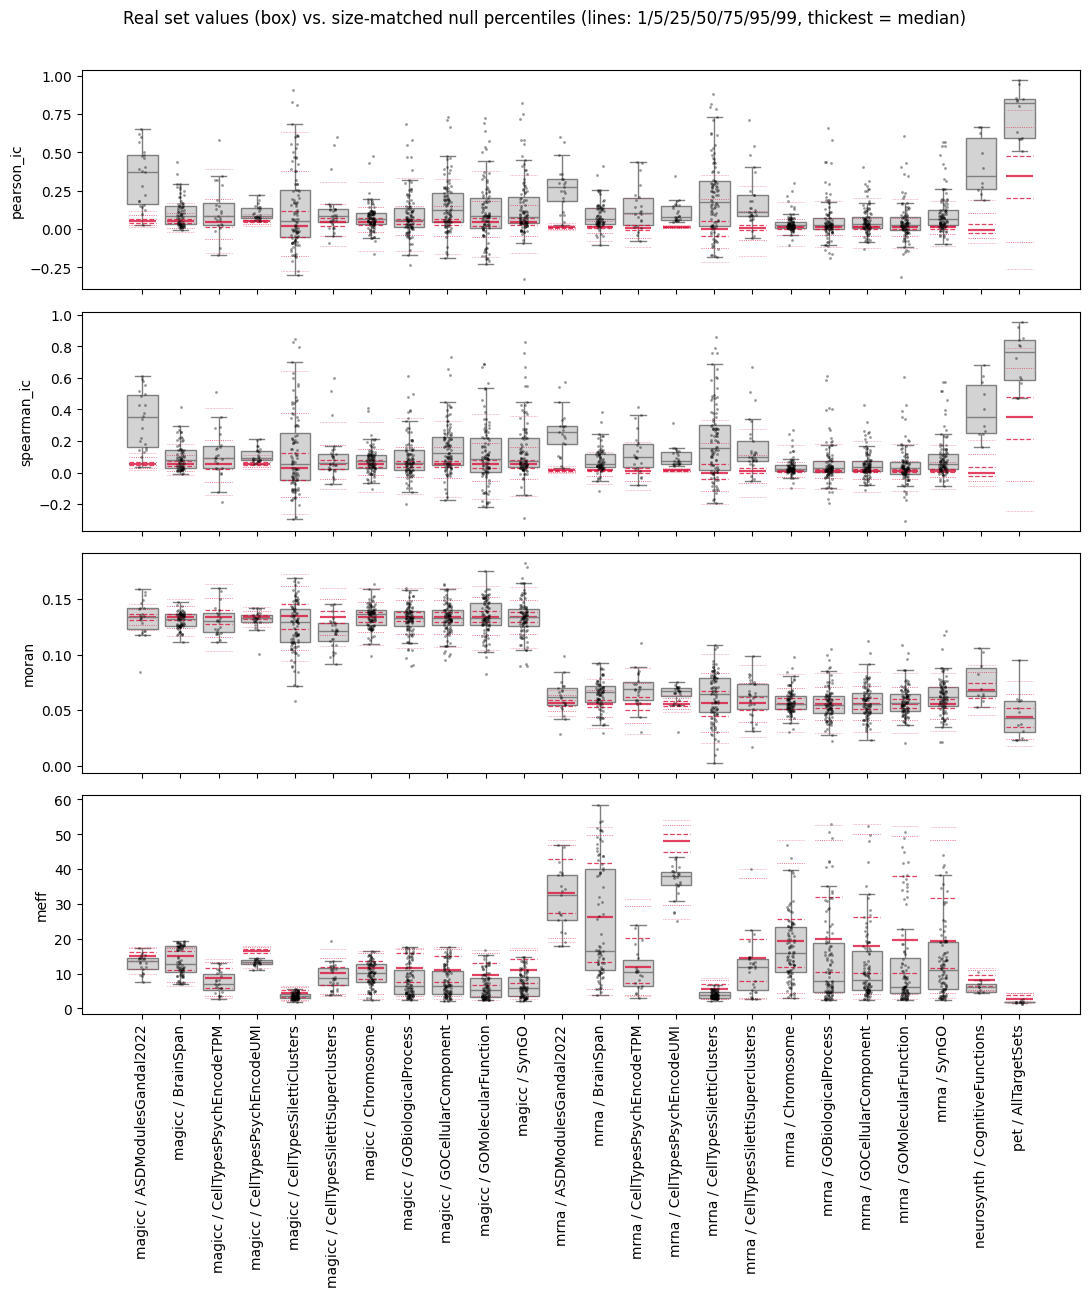

In [7]:
# Real sets' actual metric values (box + strip), compared against the size-matched null sample
# for that condition (reference lines at the null's 1/5/25/50/75/95/99th percentiles) -- rather
# than converting every real set to its own percentile rank first. This keeps the actual scale
# of each metric visible (e.g. how large the gap to the null median really is, not just whether
# it's above/below it) and shows the null's own spread alongside it.
metrics = ["pearson_ic_pct", "spearman_ic_pct", "moran_pct", "meff_pct"]  # used by the next cell
metrics_raw = ["pearson_ic", "spearman_ic", "moran", "meff"]
PCTS = [1, 5, 25, 50, 75, 95, 99]
PCT_STYLE = {1: (0.4, ":"), 5: (0.6, ":"), 25: (0.9, "--"), 50: (1.6, "-"),
             75: (0.9, "--"), 95: (0.6, ":"), 99: (0.4, ":")}

results["condition"] = results["dataset"] + " / " + results["collection"]
order = sorted(results["condition"].unique())

fig, axes = plt.subplots(len(metrics_raw), 1, figsize=(11, 3.2 * len(metrics_raw)), sharex=True)

for ax, metric in zip(axes, metrics_raw):
    sn.boxplot(data=results, x="condition", y=metric, order=order, ax=ax,
               showfliers=False, color="lightgray")
    sn.stripplot(data=results, x="condition", y=metric, order=order, ax=ax,
                 size=2, alpha=0.4, color="black")
    for xi, cond in enumerate(order):
        null_vals = null_pooled[cond][metric].dropna().values
        for p, v in zip(PCTS, np.percentile(null_vals, PCTS)):
            lw, ls = PCT_STYLE[p]
            ax.hlines(v, xi - 0.35, xi + 0.35, color="crimson", lw=lw, ls=ls, alpha=0.8)
    ax.set_ylabel(metric)
    ax.set_xlabel("")

axes[-1].set_xticklabels(axes[-1].get_xticklabels(), rotation=90)
fig.suptitle("Real set values (box) vs. size-matched null percentiles "
             "(lines: 1/5/25/50/75/95/99, thickest = median)", y=1.01)
fig.tight_layout()

,pearson_ic,spearman_ic,moran,meff
condition,,,,
magicc / ASDModulesGandal2022,0.909091,0.909091,0.272727,0.045455
magicc / BrainSpan,0.384615,0.320513,0.025641,0.512821
magicc / CellTypesPsychEncodeTPM,0.347826,0.304348,0.043478,0.043478
magicc / CellTypesPsychEncodeUMI,0.720000,0.680000,0.120000,0.000000
magicc / CellTypesSilettiClusters,0.170000,0.170000,0.040000,0.110000
magicc / CellTypesSilettiSuperclusters,0.310345,0.241379,0.034483,0.310345
magicc / Chromosome,0.180000,0.170000,0.050000,0.040000
magicc / GOBiologicalProcess,0.140000,0.130000,0.050000,0.060000
magicc / GOCellularComponent,0.360000,0.360000,0.050000,0.030000


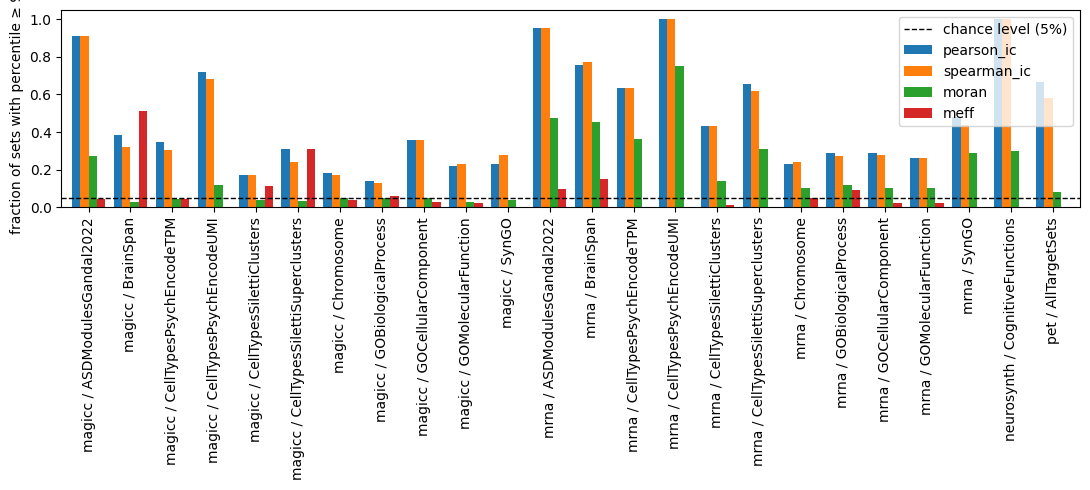

In [8]:
# Fraction of real sets that land above the 95th percentile of their null distribution
# ("clearly elevated" vs. random) -- a direct, quantitative read on the load-bearing premise.
elevated = (
    results.groupby("condition")[metrics]
    .apply(lambda d: (d >= 95).mean())
    .rename(columns=lambda c: c.replace("_pct", ""))
)

fig, ax = plt.subplots(figsize=(11, 5))
elevated.loc[order].plot(kind="bar", ax=ax, width=0.8)
ax.axhline(0.05, ls="--", color="k", lw=1, label="chance level (5%)")
ax.set_ylabel("fraction of sets with percentile ≥ 95")
ax.set_xlabel("")
ax.legend(title=None, loc="upper right")
fig.tight_layout()

elevated.loc[order]

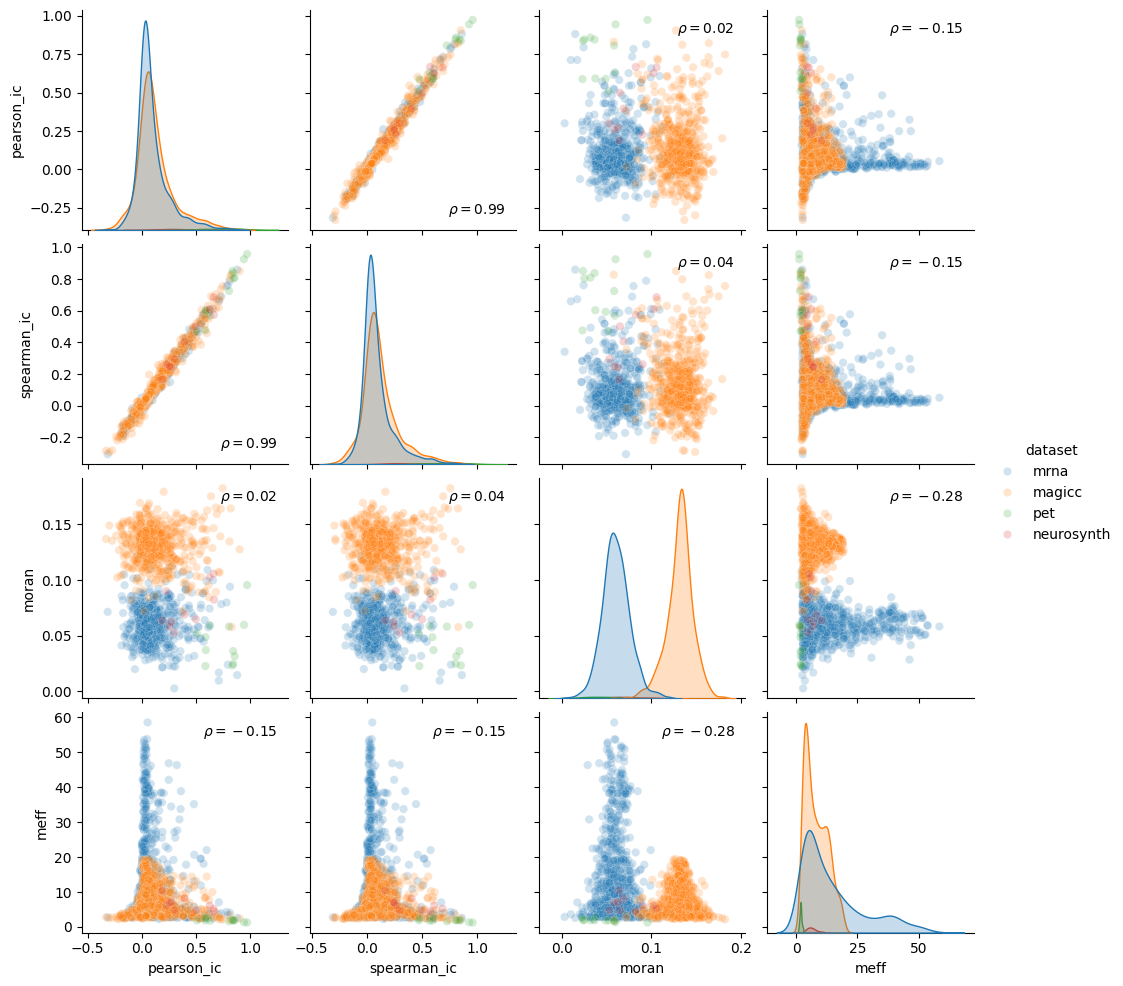

In [60]:
# Are intercorrelation, dimensionality and autocorrelation elevation redundant or independent
# signals? If e.g. pearson_ic_pct and meff_pct are tightly (anti-)correlated across sets, that
# argues against needing both as separate matching features; if not, they carry distinct
# information worth matching on separately later.
plot = sn.pairplot(results[["dataset", "pearson_ic", "spearman_ic", "moran", "meff"]], hue="dataset", plot_kws={"alpha": 0.2})
corr = plot.data.drop(columns="dataset").corr()
for ax, r in zip(plot.axes.ravel(), corr.values.ravel()):
    if r == 1:
        continue
    ax.annotate(
        rf"$\rho = {r:.2f}$", xycoords="axes fraction", 
        **({"xy": (0.95, 0.95), "ha": "right", "va": "top"} if r < 0.5 else {"xy": (0.95, 0.05), "ha": "right", "va": "bottom"})
    )


## Interpretation

**The load-bearing premise holds, unevenly.** Real sets are elevated in within-set
intercorrelation vs. a size-matched random background almost everywhere, but by how much depends
strongly on collection type: compact, biologically-coherent sets (`ASDModulesGandal2022`,
`CellTypesPsychEncodeUMI`, `BrainSpan`, Neurosynth `CognitiveFunctions`, PET `AllTargetSets`) show
60-100% of sets in the top 5% of their null; broad, hierarchically-defined categories (GO terms,
`Chromosome`, `SynGO`, `CellTypesSilettiClusters`) show only 13-29% -- still clearly above the 5%
chance level, but far weaker. An `intercorr_matched` null is well-motivated everywhere, most
impactful for the former group.

**Pearson and Spearman intercorrelation are near-interchangeable** (pooled `r = 0.99`) -- the
planned "correlation family follows the colocalization method" rule matters less than assumed in
practice; either family should work as a matching statistic regardless of the eventual
colocalization method.

**Matching must be relative to each background's own distribution, never an absolute threshold.**
MAGICC's background is uniformly more spatially autocorrelated than mrna/pet/neurosynth (bg mean
Moran's I 0.13 vs 0.04-0.07), which visually makes MAGICC's within-set values look "elevated" on
a raw scale -- but relative to *its own* background, MAGICC's within-set Moran's I is flat, not
elevated. The real within-set autocorrelation signal lives in specific mrna marker-gene
collections (`CellTypesPsychEncodeUMI` 75% >=95th pct, `ASDModulesGandal2022` 48%, `BrainSpan`
46%), not in a MAGICC-vs-mrna dataset-level effect. Confirms (does not change) the already-decided
k-NN-within-background design -- an absolute/cross-dataset threshold would have been misleading
here.

**`meff` (effective dimensionality) is consistently lower for real sets** than for random draws,
confirming it tracks a real, related-but-distinct signal. Its relationship to intercorrelation is
dataset-dependent: weak for gene-expression sets (mrna/magicc `r ~ -0.12`, i.e. largely
*independent* information -- two sets can share a mean intercorrelation but differ a lot in
cluster structure/dimensionality), much stronger for PET/Neurosynth (`r ~ -0.6` to `-0.7`, largely
*redundant* with intercorrelation there, consistent with their small, tight backgrounds). Design
implication: `meff` is worth prioritizing as a second matching feature for gene-set collections
first; for PET/Neurosynth, intercorrelation matching alone likely already constrains it.

**The pooled moran-vs-meff relationship is driven by PET/Neurosynth, not a general
gene-expression effect.** Dataset-colored scatter matrix confirms: `moran~meff` is strong for pet
(`r = -0.71`) and neurosynth (`r = -0.26`), but essentially zero for mrna (`r = -0.01`) and magicc
(`r = +0.03`). Reading the earlier pooled (uncolored) version as a universal "broader spatial
pattern -> higher chance of correlation -> lower meff" effect would have overgeneralized from the
two smallest, highest-leverage conditions.

See the issue #75 design memory for the full write-up and resulting design implications for
`intercorr_matched`.